# Figure 1 differentiation compilation

Notebook-first assembly for a data-heavy Figure 1 draft based on `hd_mea_differentiation_simulation.ipynb`. Panel `a` is intentionally reserved for a schematic that can be refined here or replaced in Illustrator later. The remaining panels use cached simulation outputs and the composable plotting helpers.

In [162]:
%matplotlib inline

from pathlib import Path
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ephax import LayoutGridPlotter, RestingActivityDataset
from ephax.modeling import HDMEADifferentiationConfig, build_differentiation_simulation
from ephax.plotting import (
    PAPER_COLORS,
    apply_paper_style,
    compose_figure,
    export_figure,
    figure,
    panel,
)
from ephax.plotting.style import LINE_WIDTHS

apply_paper_style()
plt.rcParams["figure.dpi"] = 170

## Configuration and cache

The cache stores the minimal objects needed for layout iteration. Set `FORCE_RERUN = True` after changing simulation parameters.

In [163]:
FORCE_RERUN = True
SHOW_PLACEHOLDERS = True
SAVE_FIGURE = True
CACHE_VERSION = "shared_differentiation_v1"

OUTPUT_DIR = repo_root / "outputs" / "figure1_differentiation"
CACHE_PATH = OUTPUT_DIR / "simulation_cache.pkl"
EMPIRICAL_UNION_CACHE_PATH = OUTPUT_DIR / "stim_removal_null_div12_recorded_electrode_union_cache.pkl"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sim_config = HDMEADifferentiationConfig(
    grid_columns=220,
    grid_rows=120,
    pitch_um=17.5,
    hz=45,
    v_eph_m_s=0.1,
    v_ax_m_s=0.8,
    lambda_eph_um=3000,
    axonal_decay_um=200,
    subsample_size=20,
    random_seed=0,
    plating_loss_fraction=0.50,
    target_fraction=0.40,
    milestone_step_fraction=0.10,
)

MODEL_LABELS = {
    "axonal_only": "Axonal only",
    "ephaptic_axonal": "Ephaptic-axonal",
}
MODEL_COLORS = {
    "axonal_only": PAPER_COLORS["axonal_only"],
    "ephaptic_axonal": PAPER_COLORS["ephaptic_axonal"],
    "ephaptic_term": PAPER_COLORS["ephaptic_term"],
}

PITCH_UM = sim_config.pitch_um
TARGET_COUNT = sim_config.target_count

STIM_REMOVAL_NULL_DATA_ROOT = repo_root / "ephax/data/stimRemovalNull"
STIM_REMOVAL_NULL_WELLS = [0, 1, 2, 3, 4, 5]
STIM_REMOVAL_NULL_DIV = 12
STIM_REMOVAL_NULL_FILENAME = "DIV{div}_240703_data_well{well}_exp_data.npz"
EMPIRICAL_START_SEC = 0.0
EMPIRICAL_END_SEC = 300.0
EMPIRICAL_MIN_AMP = 0.0
PLATING_METHODS_IMAGE_PATH = repo_root / "ephaptic-axonal-plating-methods.png"


In [164]:
def _cache_is_current(payload):
    return (
        isinstance(payload, dict)
        and payload.get("cache_version") == CACHE_VERSION
        and payload.get("parameters", {}).get("random_seed") == sim_config.random_seed
        and payload.get("parameters", {}).get("grid_columns") == sim_config.grid_columns
        and payload.get("parameters", {}).get("grid_rows") == sim_config.grid_rows
    )


if CACHE_PATH.exists() and not FORCE_RERUN:
    with CACHE_PATH.open("rb") as f:
        payload = pickle.load(f)
    if not _cache_is_current(payload):
        payload = build_differentiation_simulation(sim_config, model_labels=MODEL_LABELS, show_progress=True)
        payload["cache_version"] = CACHE_VERSION
        with CACHE_PATH.open("wb") as f:
            pickle.dump(payload, f)
else:
    payload = build_differentiation_simulation(sim_config, model_labels=MODEL_LABELS, show_progress=True)
    payload["cache_version"] = CACHE_VERSION
    with CACHE_PATH.open("wb") as f:
        pickle.dump(payload, f)

grid = payload["grid"]
kernels = payload["kernels"]
milestones = payload["milestones"]
ordered_labels = payload["ordered_labels"]
simulation_results = payload["simulation_results"]
history_df = payload["history_df"]
params = payload["parameters"]

print(f"Loaded Figure 1 simulation cache: {CACHE_PATH}")
print(f"Initial: {params['initial_count']:,}; plated: {params['plated_count']:,}; final target: {params['target_count']:,}")

Axonal only apoptosis:   0%|          | 0/7920 [00:00<?, ?neurons/s]

Ephaptic-axonal apoptosis:   0%|          | 0/7920 [00:00<?, ?neurons/s]

Loaded Figure 1 simulation cache: /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure1_differentiation/simulation_cache.pkl
Initial: 26,400; plated: 13,200; final target: 5,280


In [165]:
def _stim_removal_null_div_file_info():
    file_info = []
    metadata = []
    missing = []
    for well in STIM_REMOVAL_NULL_WELLS:
        path = STIM_REMOVAL_NULL_DATA_ROOT / f"well{well}" / STIM_REMOVAL_NULL_FILENAME.format(
            div=STIM_REMOVAL_NULL_DIV,
            well=int(well),
        )
        if not path.exists():
            missing.append(path)
            continue
        with np.load(path, allow_pickle=True) as data:
            sf_native = float(np.asarray(data["samp_rate"]).reshape(-1)[0])
            frameno = np.asarray(data["spike_data"]["frameno"], dtype=float)
            rec_t0 = float(np.min(frameno) / sf_native) if frameno.size else 0.0
        start_time = rec_t0 + EMPIRICAL_START_SEC
        end_time = rec_t0 + EMPIRICAL_END_SEC
        file_info.append((str(path), start_time, end_time, int(well)))
        metadata.append({"well": int(well), "path": str(path), "start_time": start_time, "end_time": end_time})
    if missing:
        raise FileNotFoundError(f"Missing stimRemovalNull DIV {STIM_REMOVAL_NULL_DIV} files: {missing}")
    return file_info, metadata


def _empirical_union_cache_is_current(payload):
    return (
        isinstance(payload, dict)
        and payload.get("cache_version") == CACHE_VERSION
        and payload.get("div") == STIM_REMOVAL_NULL_DIV
        and payload.get("wells") == STIM_REMOVAL_NULL_WELLS
    )


def _recorded_electrode_union_from_dataset(dataset):
    rows = []
    for rec_idx, rec in enumerate(dataset.recordings):
        layout_df = pd.DataFrame(rec.layout).copy()
        layout_df = layout_df[["electrode", "x", "y"]].dropna()
        layout_df["recording_idx"] = int(rec_idx)
        rows.append(layout_df)
    if not rows:
        raise ValueError("No layouts available for empirical electrode-union map.")
    union_df = pd.concat(rows, ignore_index=True)
    union_df = (
        union_df
        .groupby("electrode", as_index=False)
        .agg(x=("x", "mean"), y=("y", "mean"), n_wells=("recording_idx", "nunique"))
        .sort_values(["x", "y"])
        .reset_index(drop=True)
    )
    union_df["x_um"] = union_df["x"].astype(float)
    union_df["y_um"] = union_df["y"].astype(float)
    return union_df


if EMPIRICAL_UNION_CACHE_PATH.exists() and not FORCE_RERUN:
    with EMPIRICAL_UNION_CACHE_PATH.open("rb") as f:
        empirical_payload = pickle.load(f)
    if not _empirical_union_cache_is_current(empirical_payload):
        empirical_payload = None
else:
    empirical_payload = None

if empirical_payload is None:
    empirical_file_info, empirical_metadata = _stim_removal_null_div_file_info()
    empirical_ds = RestingActivityDataset.from_file_info(empirical_file_info, source="npz", min_amp=EMPIRICAL_MIN_AMP)
    empirical_recorded_union = _recorded_electrode_union_from_dataset(empirical_ds)
    empirical_payload = {
        "cache_version": CACHE_VERSION,
        "div": STIM_REMOVAL_NULL_DIV,
        "wells": STIM_REMOVAL_NULL_WELLS,
        "metadata": empirical_metadata,
        "recorded_electrode_union": empirical_recorded_union,
    }
    with EMPIRICAL_UNION_CACHE_PATH.open("wb") as f:
        pickle.dump(empirical_payload, f)

empirical_recorded_union = empirical_payload["recorded_electrode_union"]
print(
    f"Loaded empirical stimRemovalNull DIV {STIM_REMOVAL_NULL_DIV} recorded-electrode union "
    f"from {len(STIM_REMOVAL_NULL_WELLS)} cultures "
    f"({len(empirical_recorded_union):,} unique electrodes): {EMPIRICAL_UNION_CACHE_PATH}"
)


Loaded empirical stimRemovalNull DIV 12 recorded-electrode union from 6 cultures (4,040 unique electrodes): /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure1_differentiation/stim_removal_null_div12_recorded_electrode_union_cache.pkl


## Notebook-local draw functions

These functions are intentionally kept here until the figure stabilizes. They follow the same draw-into-existing-axes convention as package plotting functions.

In [166]:
def _clean_axes(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def draw_figure1_placeholder(_data, ax, *, show_placeholder=True, compact=True, **_opts):
    ax.set_axis_off()
    if show_placeholder:
        ax.text(0.02, 0.80, "schematic placeholder", transform=ax.transAxes, color="0.45")
        ax.text(0.02, 0.55, "Differentiation logic / RQ diagram", transform=ax.transAxes, fontsize=7)
        ax.annotate(
            "",
            xy=(0.72, 0.48),
            xytext=(0.25, 0.48),
            xycoords="axes fraction",
            arrowprops={"arrowstyle": "->", "lw": 0.9, "color": "0.25"},
        )
        ax.text(0.47, 0.57, "differentiation", transform=ax.transAxes, ha="center", fontsize=7)
        ax.add_patch(plt.Rectangle((0.01, 0.10), 0.98, 0.78, fill=False, edgecolor="0.85", linewidth=0.6, transform=ax.transAxes))
    return {"axes": ax}


def _draw_schematic_node(ax, xy, *, radius=0.012, edgecolor="0.25", facecolor="white", lw=0.7, alpha=1.0):
    # Scatter marker sizes are in points, so nodes remain circular even when the axes are wide.
    size_pt2 = (radius * 900.0) ** 2
    return ax.scatter([xy[0]], [xy[1]], s=size_pt2, facecolor=facecolor, edgecolor=edgecolor, linewidth=lw, alpha=alpha, zorder=3)


def _draw_schematic_edges(ax, positions, pairs, *, color="0.35", lw=0.45, alpha=0.6, ls="-"):
    for i, j in pairs:
        x0, y0 = positions[i]
        x1, y1 = positions[j]
        ax.plot([x0, x1], [y0, y1], color=color, lw=lw, alpha=alpha, ls=ls, solid_capstyle="round", zorder=1)


def _nearest_schematic_pairs(positions, k=2):
    coords = np.asarray(positions, dtype=float)
    pairs = set()
    for i in range(len(coords)):
        d = np.sqrt(np.sum((coords - coords[i]) ** 2, axis=1))
        nearest = np.argsort(d)[1 : k + 1]
        for j in nearest:
            pairs.add(tuple(sorted((i, int(j)))))
    return sorted(pairs)


def _schematic_cluster(center, n_nodes, *, rng, rx=0.085, ry=0.16):
    theta = rng.uniform(0, 2 * np.pi, n_nodes)
    radii = np.sqrt(rng.uniform(0.04, 1.0, n_nodes))
    return np.column_stack([center[0] + rx * radii * np.cos(theta), center[1] + ry * radii * np.sin(theta)])


def draw_network_differentiation_schematic(_data, ax, *, compact=True, seed=8, **_opts):
    """Editable schematic for panel a: plated network to sparse modular differentiation."""
    rng = np.random.default_rng(seed)
    ax.set_axis_off()
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)

    undiff_color = "#ffb6ae"
    module_a = "#ffc061"
    module_b = "#ff5757"
    bridge_color = "0.35"

    # Undifferentiated plated network: denser, broadly distributed cells with weak local links.
    left_origin = np.array([0.06, 0.16])
    left_size = np.array([0.35, 0.62])
    left_positions = left_origin + rng.random((100, 2)) * left_size
    left_pairs = _nearest_schematic_pairs(left_positions, k=2)
    _draw_schematic_edges(ax, left_positions, left_pairs, color=undiff_color, lw=0.35, alpha=0.28)
    for xy in left_positions:
        _draw_schematic_node(ax, xy, radius=0.0078, edgecolor=undiff_color, facecolor="white", lw=0.55)

    # Differentiated network: two dense modules separated by sparse long-range bridges.
    module_specs = [
        (np.array([0.66, 0.57]), module_a, 18),
        (np.array([0.84, 0.57]), module_b, 18),
    ]
    module_positions = []
    module_ranges = []
    cursor = 0
    for center, color, n_nodes in module_specs:
        xy = _schematic_cluster(center, n_nodes, rng=rng, rx=0.070, ry=0.18)
        module_positions.extend(xy)
        module_ranges.append((cursor, cursor + n_nodes, color, center))
        cursor += n_nodes

    module_positions = np.asarray(module_positions)
    for start, stop, color, center in module_ranges:
        local = module_positions[start:stop]
        local_pairs = [(i + start, j + start) for i, j in _nearest_schematic_pairs(local, k=3)]
        _draw_schematic_edges(ax, module_positions, local_pairs, color=color, lw=0.45, alpha=0.45)
        halo = plt.Circle(center, 0.125, facecolor="none", edgecolor=color, linewidth=0.6, linestyle="--", alpha=0.55, transform=ax.transAxes)
        ax.add_patch(halo)
        for xy in local:
            _draw_schematic_node(ax, xy, radius=0.0078, edgecolor=color, facecolor="white", lw=0.55)

    sparse_bridges = [
        (module_ranges[0][0] + 3, module_ranges[1][0] + 4),
        (module_ranges[0][0] + 9, module_ranges[1][0] + 12),
    ]
    _draw_schematic_edges(ax, module_positions, sparse_bridges, color=bridge_color, lw=0.45, alpha=0.72, ls="--")

    ax.annotate(
        "",
        xy=(0.54, 0.50),
        xytext=(0.44, 0.50),
        xycoords="axes fraction",
        arrowprops={"arrowstyle": "->", "lw": 0.9, "color": "0.2"},
    )
    ax.text(0.235, 0.88, "undifferentiated network", transform=ax.transAxes, ha="center", fontsize=7)
    ax.text(0.75, 0.88, "differentiated network", transform=ax.transAxes, ha="center", fontsize=7)
    ax.text(0.75, 0.14, "Hypothesis: Ephaptic-axonal interactions\n predict inter-patch distance", transform=ax.transAxes, ha="center", fontsize=6, color="0.35")
    return {"axes": ax}


def draw_plating_methods_image(image_path, ax, *, compact=True, **_opts):
    image = plt.imread(image_path)
    ax.imshow(image, aspect="equal")
    ax.set_axis_off()
    ax.set_anchor("C")
    return {"axes": ax, "image": image}


def draw_kernel_comparison(data, axes, *, compact=True, show_legend=True, **_opts):
    ax_left, ax_right = axes
    r_um = data["r_um"]
    xmax = min(float(r_um.max()), 3600.0)

    ax_left.plot(r_um, data["axonal"], color=MODEL_COLORS["axonal_only"], lw=LINE_WIDTHS["emphasis"])
    ax_left.axhline(0.0, color="0.35", lw=LINE_WIDTHS["thin"])
    ax_left.set_title("axonal only", color=MODEL_COLORS["axonal_only"])
    ax_left.set_ylabel("Interaction kernel (a.u.)")


    ax_right.plot(r_um, data["ephaptic_axonal"], color=MODEL_COLORS["ephaptic_axonal"], lw=LINE_WIDTHS["emphasis"])
    ax_right.axvline(data["wavelength_um"], color="0.35", lw=LINE_WIDTHS["thin"], ls="--")
    ax_right.axhline(0.0, color="0.35", lw=LINE_WIDTHS["thin"])
    ax_right.text(data["wavelength_um"]/3700, 0.88, f"λ(45 Hz) = {int(data['wavelength_um'])} μm", transform=ax_right.transAxes, ha="right", fontsize=6, color="0.35")
    ax_right.set_title("ephaptic-axonal", color=MODEL_COLORS["ephaptic_axonal"])
    if show_legend is not False:
        ax_right.legend(loc="upper right", frameon=False)

    for ax in axes:
        ax.set_xlim(0.0, xmax)
        ax.set_xlabel("Distance (um)")
        _clean_axes(ax)
    return {"axes": axes}


def draw_node_map(ax, nodes_df, grid, *, title, color, background=None, point_size=1):
    ax.set_facecolor("black")
    if background is not None:
        ax.scatter(background["x_um"], background["y_um"], s=0.05, color="0.20", linewidths=0, rasterized=True)
    ax.scatter(nodes_df["x_um"], nodes_df["y_um"], s=point_size, color=color, linewidths=0, rasterized=True)
    ax.set_aspect("equal")
    ax.set_xlim(-PITCH_UM, grid["x_um"].max() + PITCH_UM)
    ax.set_ylim(-PITCH_UM, grid["y_um"].max() + PITCH_UM)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    for spine in ax.spines.values():
        spine.set_color("0.15")
        spine.set_linewidth(0.5)


def draw_model_outcome_maps(data, axes, *, compact=True, **_opts):
    ax_axonal, ax_ephaptic, *extra_axes = axes
    background = data["simulation_results"]["axonal_only"]["plated_initial"]
    draw_node_map(
        ax_axonal,
        data["simulation_results"]["axonal_only"]["final_active"],
        data["grid"],
        title="axonal only",
        color=MODEL_COLORS["axonal_only"],
        background=background,
    )
    draw_node_map(
        ax_ephaptic,
        data["simulation_results"]["ephaptic_axonal"]["final_active"],
        data["grid"],
        title="ephaptic-axonal",
        color=MODEL_COLORS["ephaptic_axonal"],
        background=background,
    )
    rendered = {"axes": axes}
    if extra_axes and data.get("empirical_recorded_union") is not None:
        draw_node_map(
            extra_axes[0],
            data["empirical_recorded_union"],
            data["grid"],
            title=f"empirically recorded activity",
            color=PAPER_COLORS["highlight"],
            background=None,
        )
        rendered["empirical_recorded_union"] = extra_axes[0]
    for ax in extra_axes[1:]:
        ax.set_axis_off()
    return rendered


def draw_milestone_strip(data, axes, *, compact=True, **_opts):
    labels = [label for label in ["90%", "70%", "50%"] if label in data["milestones"]]
    for ax, label in zip(axes, labels):
        nodes = data["simulation_results"]["ephaptic_axonal"]["milestone_snapshots"][label]
        draw_node_map(
            ax,
            nodes,
            data["grid"],
            title=f"{label} of initialised neurons remaining",
            color=MODEL_COLORS["ephaptic_axonal"],
            background=None,
        )
    for ax in axes[len(labels):]:
        ax.set_axis_off()
    return {"axes": axes}

In [167]:
def two_panel_axes_factory(fig, subplotspec):
    gs = subplotspec.subgridspec(1, 2, wspace=0.18)
    return fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])


def three_panel_axes_factory(fig, subplotspec):
    gs = subplotspec.subgridspec(1, 3, wspace=0.14)
    return tuple(fig.add_subplot(gs[0, idx]) for idx in range(3))

## Standalone panel checks

Quick checks for individual panel content before composing the full figure.

/var/folders/xq/zsnxhck50qdbl4qw73tdb_dw0000gn/T/ipykernel_80307/1168397222.py:143: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_right.legend(loc="upper right", frameon=False)


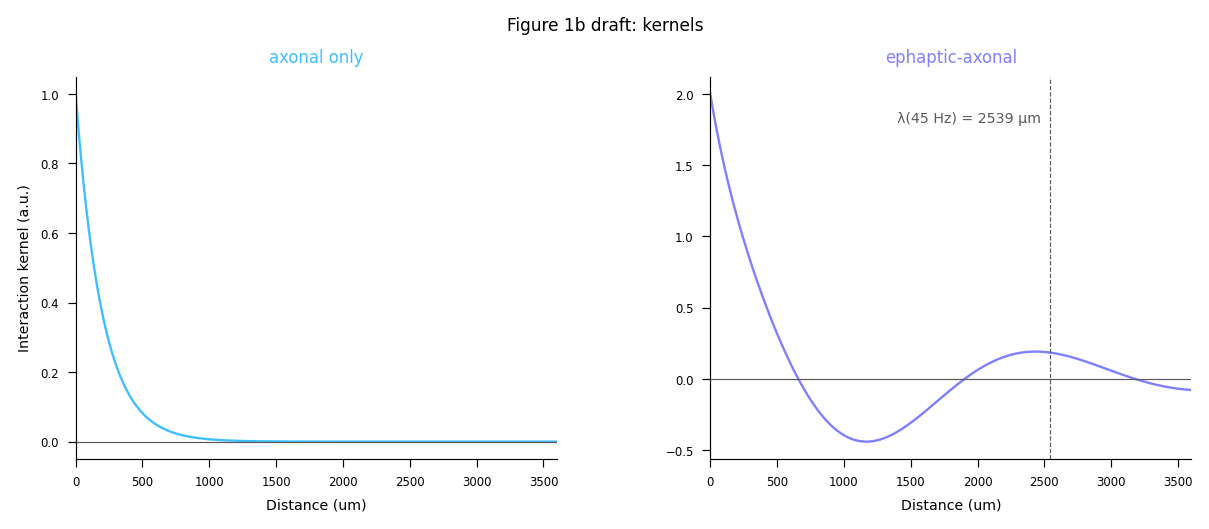

In [168]:
fig = plt.figure(figsize=(7.0, 3.0), constrained_layout=True)
axes = two_panel_axes_factory(fig, fig.add_gridspec(1, 1)[0, 0])
draw_kernel_comparison(kernels, axes)
_ = fig.suptitle("Figure 1b draft: kernels")

## Draft panel a schematic

First compose the network-differentiation schematic as a standalone editable Matplotlib panel before deciding whether to place it into the full Figure 1 layout.

{'axes': <Axes: >}

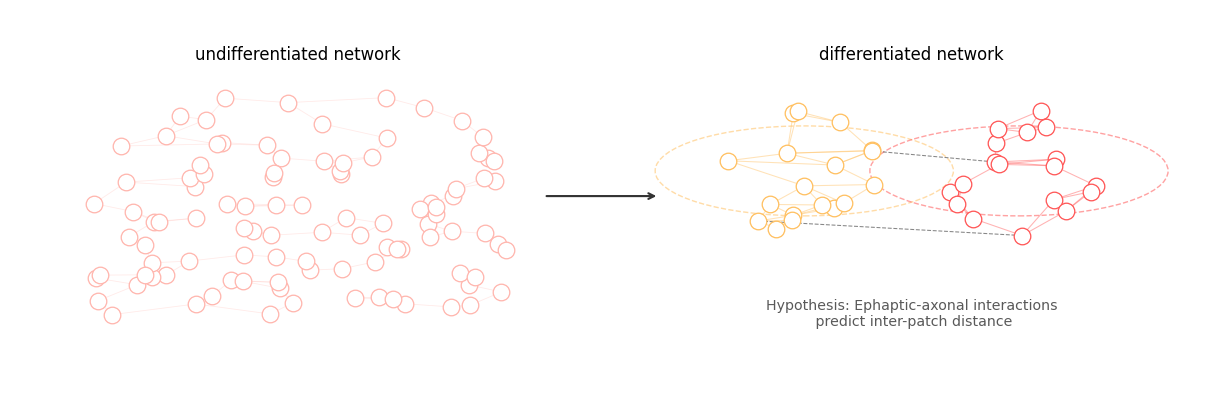

In [169]:
# Standalone draft for panel a before integration into the composed figure.
fig, ax = plt.subplots(figsize=(7.1, 2.2), constrained_layout=True)
draw_network_differentiation_schematic(None, ax)


## Compose Figure 1 draft

The 12-column layout is intentionally conservative. Panel `a` is editable placeholder content; panels `b-e` are simulation-derived.

/var/folders/xq/zsnxhck50qdbl4qw73tdb_dw0000gn/T/ipykernel_80307/1168397222.py:143: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_right.legend(loc="upper right", frameon=False)


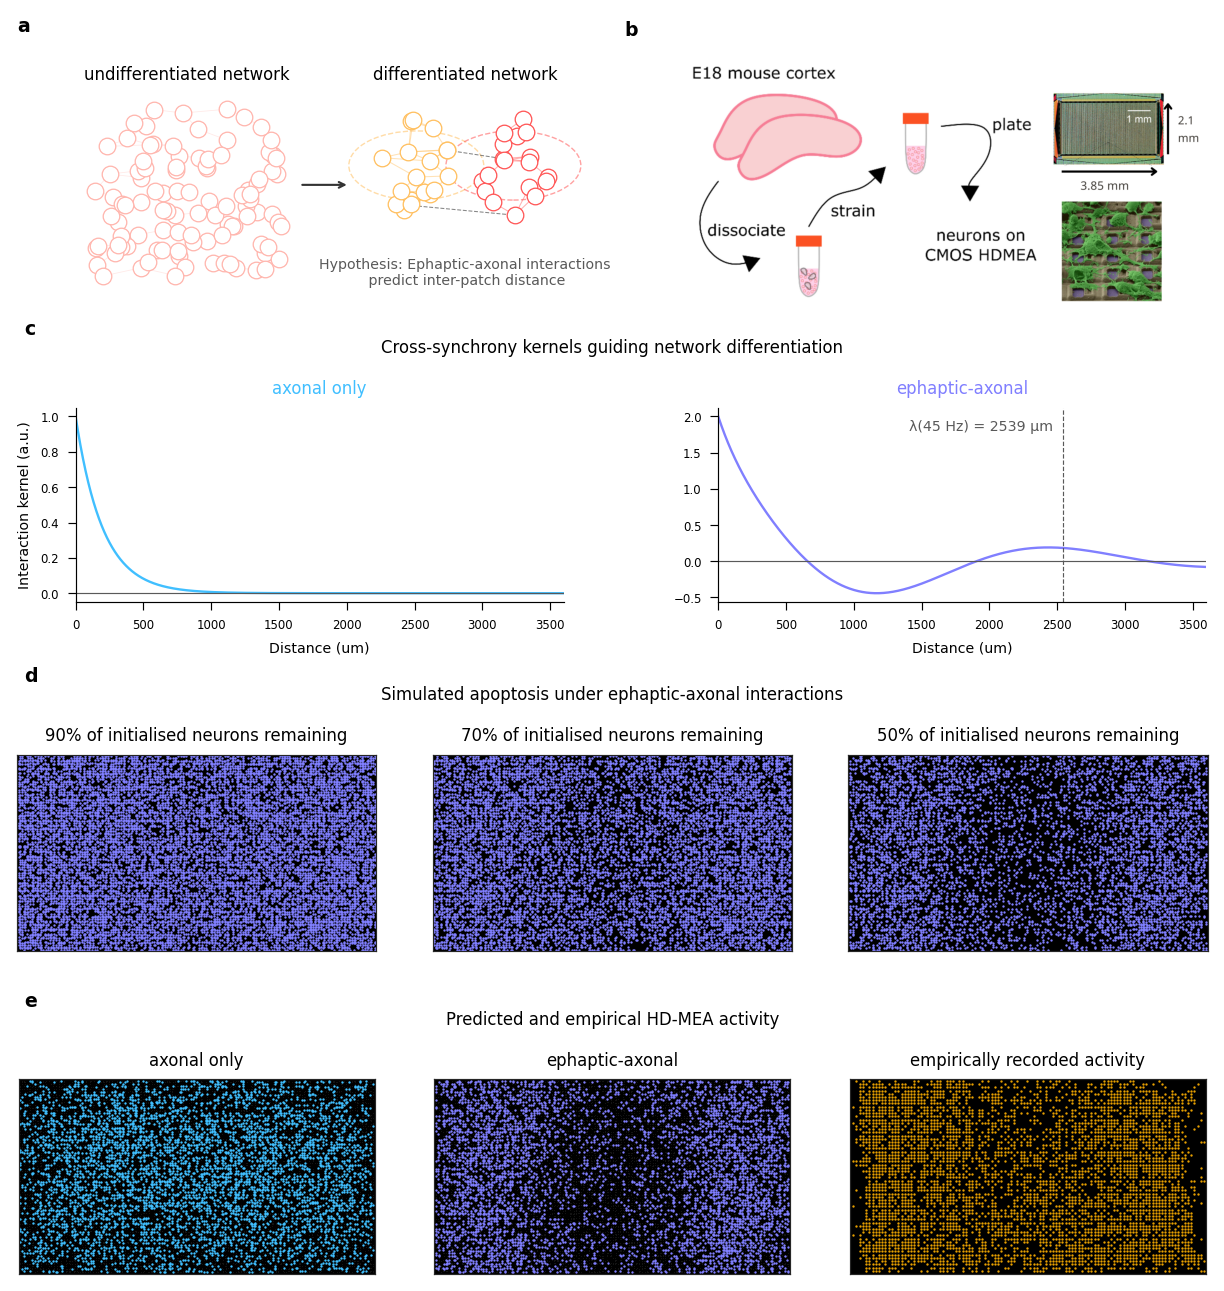

In [170]:
figure1_data = {
    "grid": grid,
    "kernels": kernels,
    "history_df": history_df,
    "simulation_results": simulation_results,
    "milestones": milestones,
    "empirical_recorded_union": empirical_recorded_union,
}

composed = compose_figure(
    figure(width="two_column", height_mm=190.0, rows=[1.05, 1.10, 1.05, 0.90], row_gaps=[0.16, 0.20, 0.20]),
    [
        panel(
            "schematic",
            label="a",
            loc=(0, 0, 1, 6),
            draw=draw_network_differentiation_schematic,
            data=None,
            options={"show_placeholder": SHOW_PLACEHOLDERS},
        ),
        panel(
            "plating_methods",
            label="b",
            loc=(0, 6, 1, 6),
            draw=draw_plating_methods_image,
            data=PLATING_METHODS_IMAGE_PATH,
        ),
        panel(
            "kernels",
            label="c",
            suptitle="Cross-synchrony kernels guiding network differentiation",
            loc=(1, 0, 1, 12),
            draw=draw_kernel_comparison,
            data=kernels,
            axes_factory=two_panel_axes_factory,
        ),
        panel(
            "milestones",
            label="d",
            suptitle="Simulated apoptosis under ephaptic-axonal interactions",
            loc=(2, 0, 1, 12),
            draw=draw_milestone_strip,
            data=figure1_data,
            axes_factory=three_panel_axes_factory,
        ),
        panel(
            "outcomes",
            label="e",
            suptitle="Predicted and empirical HD-MEA activity",
            loc=(3, 0, 1, 12),
            draw=draw_model_outcome_maps,
            data=figure1_data,
            axes_factory=three_panel_axes_factory,
        ),

    ],
)

## Export

PDF and SVG preserve editable vector content where Matplotlib supports it. Dense node maps are rasterized within the vector containers to keep files manageable.

In [171]:
if SAVE_FIGURE:
    saved_paths = export_figure(composed.fig, OUTPUT_DIR / "figure1_differentiation_draft")
    print("Saved:")
    for path in saved_paths:
        print(f"- {path}")

Saved:
- /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure1_differentiation/figure1_differentiation_draft.pdf
- /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure1_differentiation/figure1_differentiation_draft.svg
- /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure1_differentiation/figure1_differentiation_draft.png


## Promotion notes

Keep editing layout and panel choices here. Once the figure content stabilizes, the reusable pieces worth promoting are likely the kernel comparison and HD-MEA node-map rendering.